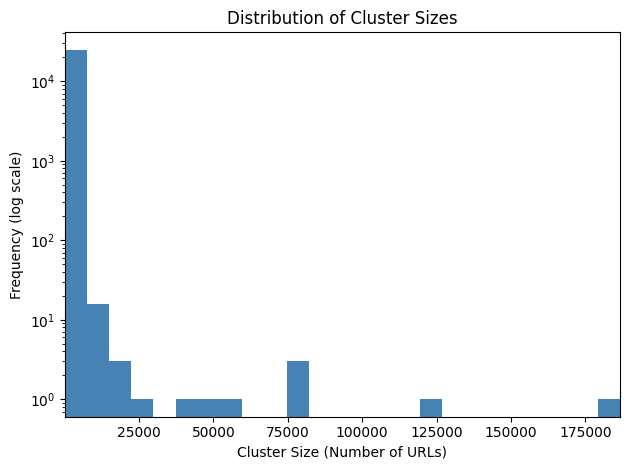

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_27112025.csv'))
cluster_size = df['number_of_site_data']

# Create histogram with thick bars
counts, bins, patches = plt.hist(
    cluster_size,
    bins=25,              # fewer bins -> thicker bars
    color='steelblue',
    edgecolor='none',
    rwidth=1.0            # bars touch each other
)

# Apply logarithmic scale to y-axis
plt.yscale('log')

# Remove whitespace on both sides
plt.xlim(bins[0], bins[-1])

# Add axis labels and title
plt.title('Distribution of Cluster Sizes')
plt.xlabel('Cluster Size (Number of URLs)')
plt.ylabel('Frequency (log scale)')

# Optimize layout
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'cluster_sizes_bar.pdf'), dpi=600)
plt.show()


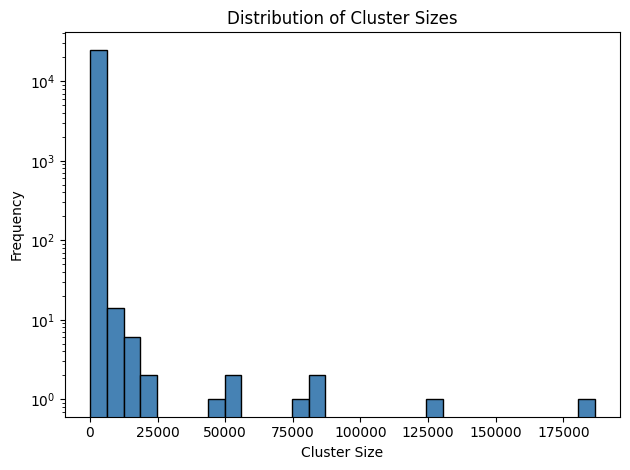

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

raw_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_raw_27112025.csv'))
raw_cluster_size = raw_df['cluster_size'].tolist()

df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_27112025.csv'))
cluster_size = df['number_of_site_data']

plt.hist(cluster_size, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Cluster Size")
plt.ylabel("Frequency")
plt.yscale('log')
plt.title("Distribution of Cluster Sizes")
plt.tight_layout()
plt.show()


NameError: name 'x' is not defined

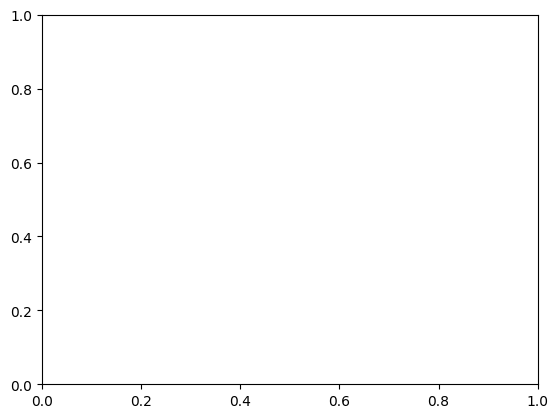

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

edgecolors = ['green', 'red', 'blue']

ax.hist(x, nbins=30, fill=False, histtype="step", stacked=True,
        edgecolor=edgecolors, label=edgecolors)
ax.legend()
ax.set_title('Distribution of Cluster Sizes')

plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

raw_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_raw_27112025.csv'))
raw_cluster_size = raw_df['cluster_size'].tolist()

total_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_27112025.csv'))
cluster_size = total_df['number_of_site_data'].tolist()

df = pd.DataFrame({'raw_cluster_size': sorted(raw_cluster_size),'cluster_size': sorted(cluster_size)}, columns=['raw_cluster_size','cluster_size'])

fig, ax = plt.subplots()
edgecolors = ['green', 'red']

ax.hist(df, 30, fill=False, histtype="step", stacked=True,
        edgecolor=edgecolors, label=edgecolors)
ax.legend()
ax.yscale('log')
ax.set_title('Distribution of Cluster Sizes')

plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

raw_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_raw_27112025.csv'))
raw_cluster_size = raw_df['cluster_size'].tolist()

total_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_27112025.csv'))
cluster_size = total_df['number_of_site_data'].tolist()

df = pd.DataFrame({'raw_cluster_size': sorted(raw_cluster_size),'cluster_size': sorted(cluster_size)}, columns=['raw_cluster_size','cluster_size'])

fig, (ax0, ax1) = plt.subplots(1, 2)

ax0.hist(raw_cluster_size, bins=30, color='steelblue', edgecolor='black')
ax0.set_title('Distribution of Raw Cluster Sizes')
ax0.set_yscale('log')
ax0.set_xlabel('Cluster Size (Number of Scripts)')
ax0.set_ylabel('Frequency (log scale)')

ax1.hist(cluster_size, bins=30, color='green', edgecolor='black')
ax1.set_title('Distribution of Cluster Sizes')
ax1.set_yscale('log')
ax1.set_xlabel('Cluster Size (Number of URLs)')

fig.tight_layout()
plt.savefig("cluster_sizes_hist.pdf", dpi=600)
plt.show()

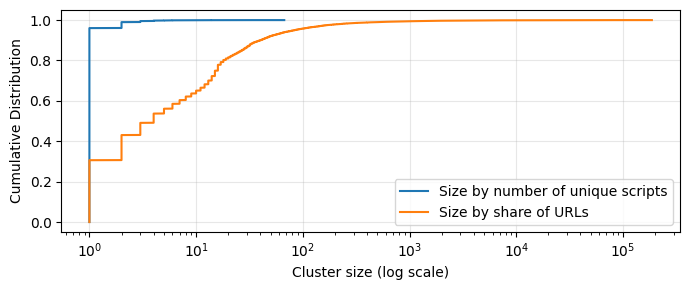

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
raw_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_raw_27112025.csv'))
raw_cluster_size = raw_df['cluster_size'].to_numpy()

total_df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_27112025.csv'))
cluster_size = total_df['number_of_site_data'].to_numpy()

# Sort values for empirical CDF
raw_sorted = np.sort(raw_cluster_size)
total_sorted = np.sort(cluster_size)

# Empirical CDF computation
raw_cdf = np.arange(1, len(raw_sorted) + 1) / len(raw_sorted)
total_cdf = np.arange(1, len(total_sorted) + 1) / len(total_sorted)

# Plot CDF with two lines
plt.figure(figsize=(7, 3))

plt.plot(raw_sorted, raw_cdf, label='Size by number of unique scripts', linewidth=1.5)
plt.plot(total_sorted, total_cdf, label='Size by share of URLs', linewidth=1.5)

plt.xlabel('Cluster size (log scale)')
plt.xscale('log')
plt.legend(fontsize=10)
plt.ylabel('Cumulative Distribution')
# plt.title('CDF of Cluster Sizes')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("cluster_sizes_cdf.pdf", dpi=600)
plt.show()


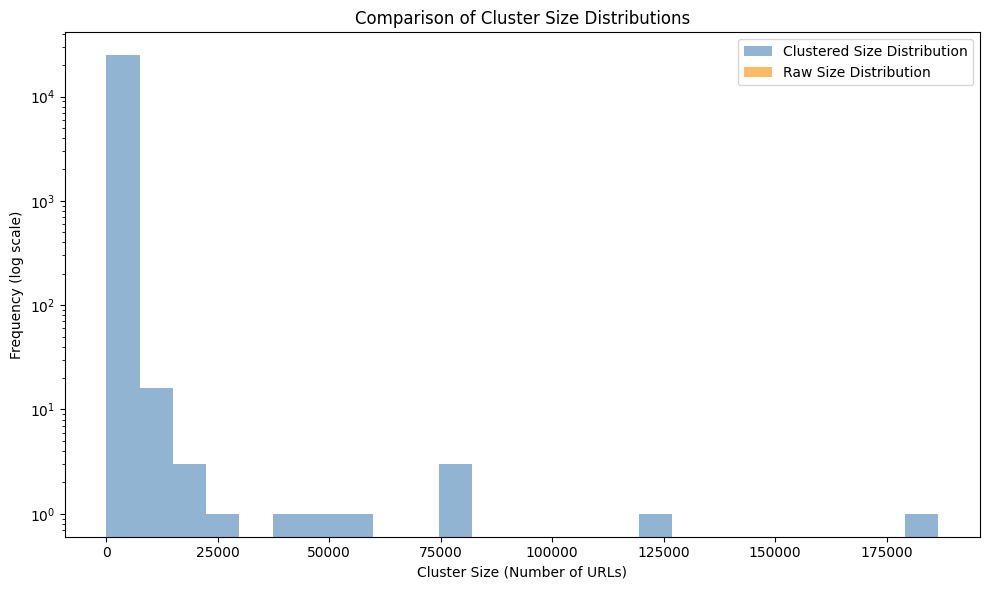

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------
# Load original clustered data
# --------------------------------------------------------
df_main = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes_27112025.csv'))
cluster_size_main = df_main['number_of_site_data']

# --------------------------------------------------------
# Load raw cluster size data
# --------------------------------------------------------
raw_cluster_path = os.path.join(os.getcwd(), 'cluster_sizes_raw_27112025.csv')
df_raw = pd.read_csv(raw_cluster_path)
cluster_size_raw = df_raw['cluster_size']

# --------------------------------------------------------
# Build common bin edges (scientifically necessary!)
# Ensures comparability and interpretable overlapping bars
# --------------------------------------------------------
all_values = pd.concat([cluster_size_main, cluster_size_raw])
bins = 25  # fixed number of bins

# --------------------------------------------------------
# Create plot
# --------------------------------------------------------
plt.figure(figsize=(10, 6))

# Histogram 1 – original clustered data
plt.hist(
    cluster_size_main,
    bins=bins,
    alpha=0.6,
    label='Clustered Size Distribution',
    color='steelblue',
    edgecolor='none',
    rwidth=1.0
)

# Histogram 2 – raw cluster size data
plt.hist(
    cluster_size_raw,
    bins=bins,
    alpha=0.6,
    label='Raw Size Distribution',
    color='darkorange',
    edgecolor='none',
    rwidth=1.0
)

# --------------------------------------------------------
# Logarithmic scale for vertical axis
# --------------------------------------------------------
plt.yscale('log')

# Axis labels and title
plt.title('Comparison of Cluster Size Distributions')
plt.xlabel('Cluster Size (Number of URLs)')
plt.ylabel('Frequency (log scale)')

# Legend
plt.legend()

# Improve layout
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(os.getcwd(), 'cluster_sizes_combined.pdf'), dpi=600)

plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(os.path.join(os.getcwd(), 'cluster_sizes.csv'))
cluster_size = df['number_of_elements']

# Replace inf values and remove non-positive entries (log scale requires > 0)
cluster_size = cluster_size.replace([np.inf, -np.inf], np.nan).dropna()
cluster_size = cluster_size[cluster_size > 0]

# Define logarithmically spaced bins
bins = np.logspace(np.log10(cluster_size.min()), np.log10(cluster_size.max()), 40)

# Create histogram with thick bars
counts, bins, patches = plt.hist(
    cluster_size,
    bins=bins,
    color='steelblue',
    edgecolor='none',
    rwidth=1.0,
    alpha=0.6,
    label='Histogram'
)

# Add KDE curve in log space
sns.kdeplot(
    x=cluster_size,
    bw_adjust=0.5,
    color='darkred',
    lw=2,
    log_scale=True,
    label='KDE (log-binned)'
)

# Apply logarithmic scales
plt.xscale('log')
plt.yscale('log')

# Remove whitespace
plt.xlim(cluster_size.min(), cluster_size.max())

# Add title, labels, legend
plt.title('Distribution of Cluster Sizes with Log-Binned Density Curve')
plt.xlabel('Cluster Size (log scale)')
plt.ylabel('Frequency / Density (log scale)')
plt.legend()

# Optimize layout
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'cluster_sizes_kde.pdf'), dpi=600)
plt.show()


# Cluster RAW Size Bar Chart

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

raw_cluster_size_data = os.path.join(os.getcwd(), 'raw_cluster_sizes.csv')
df = pd.read_csv(raw_cluster_size_data)

df.head()


In [ ]:
plt.figure(figsize=(8, 5))

# Horizontaler Barplot der Prozentwerte
bars = plt.barh(df["cluster_size"], df["percentage"])

# Logarithmische Skalierung der x-Achse
plt.xscale("log")

plt.xlabel("percentage (%) [log scale]")
plt.ylabel("cluster_size")
plt.title("Cluster Size Distribution (percentage, log scale)")

# Balken mit f0_ beschriften
for bar, value in zip(bars, df["f0_"]):
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["percentage"], df["cluster_size"])

plt.xscale("log")
plt.xlabel("percentage (%) [log scale]")
plt.ylabel("cluster_size")
plt.title("Cluster Size Distribution (Dot Plot, log scale)")

for x, y, label in zip(df["percentage"], df["cluster_size"], df["f0_"]):
    plt.text(x, y, str(label), va="center", ha="left")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hlines(df["cluster_size"], 0, df["percentage"])
plt.scatter(df["percentage"], df["cluster_size"], s=80)

plt.xscale("log")
plt.xlabel("percentage (%) [log scale]")
plt.ylabel("cluster_size")
plt.title("Cluster Size Distribution (Lollipop Plot)")

for x, y, label in zip(df["percentage"], df["cluster_size"], df["f0_"]):
    plt.text(x, y, str(label), va="center", ha="left")

plt.tight_layout()
plt.show()